# Build an Artificial neural network to predict customer churn in a bank dataset

## Importing the libraries

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

In [23]:
tf.__version__

'2.19.0'

## Importing the dataset

In [44]:
dataset = pd.read_csv('Churn_Modelling.csv')
dataset

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [25]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


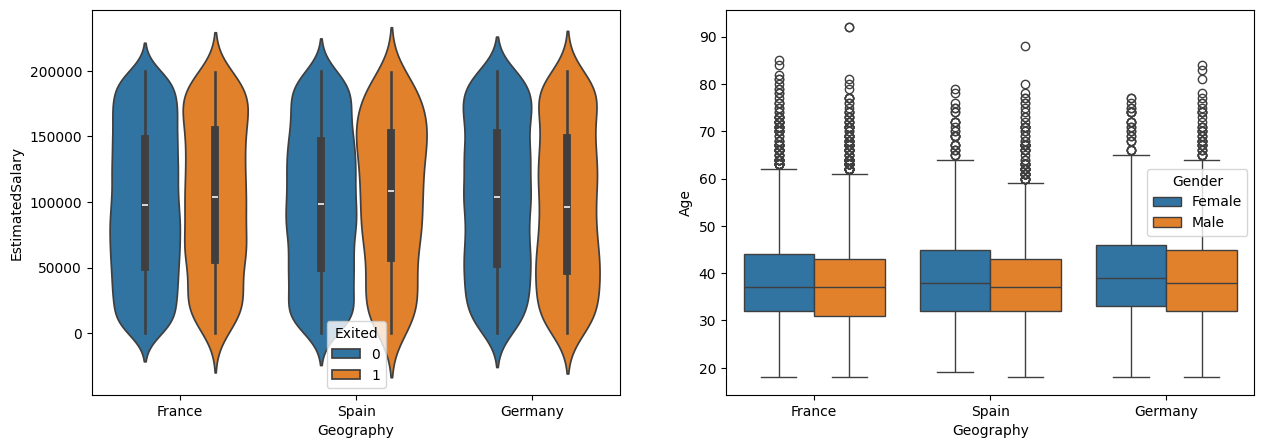

In [26]:
import seaborn as sns

fig, axe = plt.subplots(1, 2, figsize=(15, 5))

sns.violinplot(dataset, x='Geography', y='EstimatedSalary', hue="Exited", ax=axe[0])
sns.boxplot(dataset, x='Geography', y='Age', hue='Gender')
fig.show()

## 01-Data preprocessing

In [27]:
x = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values
x[:3, : ], y[:3]

(array([[619, 'France', 'Female', 42, 2, 0.0, 1, 1, 1, 101348.88],
        [608, 'Spain', 'Female', 41, 1, 83807.86, 1, 0, 1, 112542.58],
        [502, 'France', 'Female', 42, 8, 159660.8, 3, 1, 0, 113931.57]],
       dtype=object),
 array([1, 0, 1]))

### Encoding categorical data

#### Label Encoding the "Gender" column

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
x[:, 2] = le.fit_transform(x[:, 2])

#### One Hot Encoding the "Gender" column

In [29]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder='passthrough')
x = np.array(ct.fit_transform(x))
x

array([[1.0, 0.0, 0.0, ..., 1, 1, 101348.88],
       [0.0, 0.0, 1.0, ..., 0, 1, 112542.58],
       [1.0, 0.0, 0.0, ..., 1, 0, 113931.57],
       ...,
       [1.0, 0.0, 0.0, ..., 0, 1, 42085.58],
       [0.0, 1.0, 0.0, ..., 1, 0, 92888.52],
       [1.0, 0.0, 0.0, ..., 1, 0, 38190.78]], dtype=object)

### Split the dataset into the Training set and Test set

In [49]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

### Feature Scaling

In [50]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [32]:
x_train[:3]

array([[-1.01460667, -0.5698444 ,  1.74309049,  0.16958176, -1.09168714,
        -0.46460796,  0.00666099, -1.21571749,  0.8095029 ,  0.64259497,
        -1.03227043,  1.10643166],
       [-1.01460667,  1.75486502, -0.57369368, -2.30455945,  0.91601335,
         0.30102557, -1.37744033, -0.00631193, -0.92159124,  0.64259497,
         0.9687384 , -0.74866447],
       [ 0.98560362, -0.5698444 , -0.57369368, -1.19119591, -1.09168714,
        -0.94312892, -1.031415  ,  0.57993469, -0.92159124,  0.64259497,
        -1.03227043,  1.48533467]])

## 02-Building the ANN

In [33]:
# Initializing the ANN
ann = tf.keras.models.Sequential()

In [34]:
# Adding the input layer and first hidden layer
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

In [35]:
# Adding the second hidden layer
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

In [36]:
# Adding the output
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

## 03-Training the ANN

### Compiling the ANN

In [37]:
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

### Training the ANN on the training set

In [38]:
x_train = x_train.astype(np.float32)
y_train = y_train.astype(np.float32)

In [39]:
ann.fit(x_train, y_train, batch_size=32, epochs = 100)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7196 - loss: 0.5962
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7997 - loss: 0.4829
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8080 - loss: 0.4516
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8177 - loss: 0.4247
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8223 - loss: 0.4169
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8259 - loss: 0.4135
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8327 - loss: 0.4042
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8473 - loss: 0.3773
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8522 - loss: 0.3650
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8534 - loss: 0.3669
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8577 - loss: 0.3570
Epoch 12/100
250/250 ━━━━━━━━━━━━━━━━━━━

## 04-Making the predictions and evaluating the model

### Predicting the result of a single observation

In [68]:
data = [[600,'France', 'Male', 40, 3, 60000, 2, 1, 1, 50000]]
data = np.array(data)
data[:, 2] = le.transform(data[:, 2])
data = np.array(ct.transform(data))
data = sc.transform(data)
data

array([[ 0.98560362, -0.5698444 , -0.57369368, -0.52111599,  0.91601335,
         0.10961719, -0.68538967, -0.2569057 ,  0.8095029 ,  0.64259497,
         0.9687384 , -0.87203322]])

In [69]:
data_pred = ann.predict(data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [71]:
data_pred > 0.5

array([[False]])

### Predicting the Test set results

In [141]:
y_pred = ann.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [142]:
y_pred = (y_pred > 0.5).astype(int)

### Making the Confusion matrix

0.865


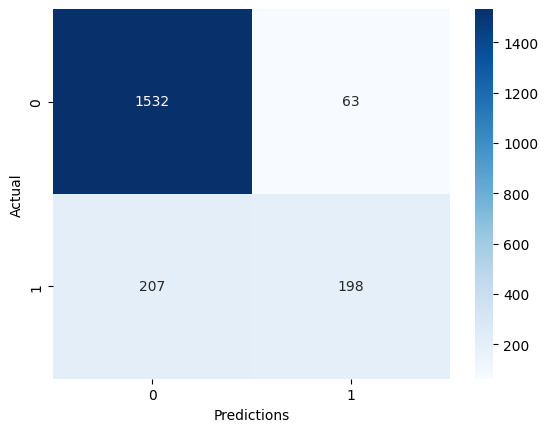

In [147]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
print(accuracy_score(y_test, y_pred))
sns.heatmap(cm, annot=True, cmap="Blues", fmt='.0f')
plt.xlabel("Predictions")
plt.ylabel("Actual")

plt.show()